# Analisi dei Tempi di Esecuzione (Benchmark)

Questo notebook confronta i risultati ottenuti e salvati in `results_local.csv`. Genera dei grafici per valutare la scalabilità e le differenze di performance tra MapReduce, Hive, Spark Core e Spark SQL e salva i risultati nella cartella `plots/`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assicuriamoci che la cartella plots esista
os.makedirs('plots', exist_ok=True)

# Impostiamo lo stile dei grafici
sns.set_theme(style='whitegrid')

# Caricamento dei risultati
df = pd.read_csv('results_local.csv').dropna(how='all')

# Pulizia base per evitare problemi con righe vuote
df = df[df['analysis'] != 'analysis']

# Convertiamo i tipi di dato
df['input_size_mb'] = df['input_size_mb'].astype(float)
df['elapsed_sec'] = df['elapsed_sec'].astype(float)
df['analysis'] = df['analysis'].astype(str)

df.head(6)

,timestamp,analysis,technology,environment,input_file,input_size_mb,input_rows,elapsed_sec,exit_code,notes
0,2026-05-05 11:53:40,3.1,mapreduce,local,data/samples/sample_010pct.csv,35.39,703885,27.74,0,sample_010pct
1,2026-05-05 11:54:09,3.1,mapreduce,local,data/samples/sample_025pct.csv,88.47,1759713,29.33,0,sample_025pct
2,2026-05-05 11:54:43,3.1,mapreduce,local,data/samples/sample_050pct.csv,176.95,3519426,33.44,0,sample_050pct
3,2026-05-05 11:55:22,3.1,mapreduce,local,data/cleaned/flight_data_2024_cleaned.csv,353.89,7038851,38.75,0,full_dataset
4,2026-05-05 16:50:38,3.1,mapreduce,local,data/samples/sample_125pct.csv,449.00,8798563,43.00,0,125pct
5,2026-05-05 17:03:02,3.1,mapreduce,local,data/samples/sample_150pct.csv,545.00,10558276,46.00,0,150pct


## 1. Scalabilità: Tempo di Esecuzione rispetto alla Dimensione dell'Input
Confrontiamo come cresce il tempo di esecuzione per ogni tecnologia all'aumentare dei dati.

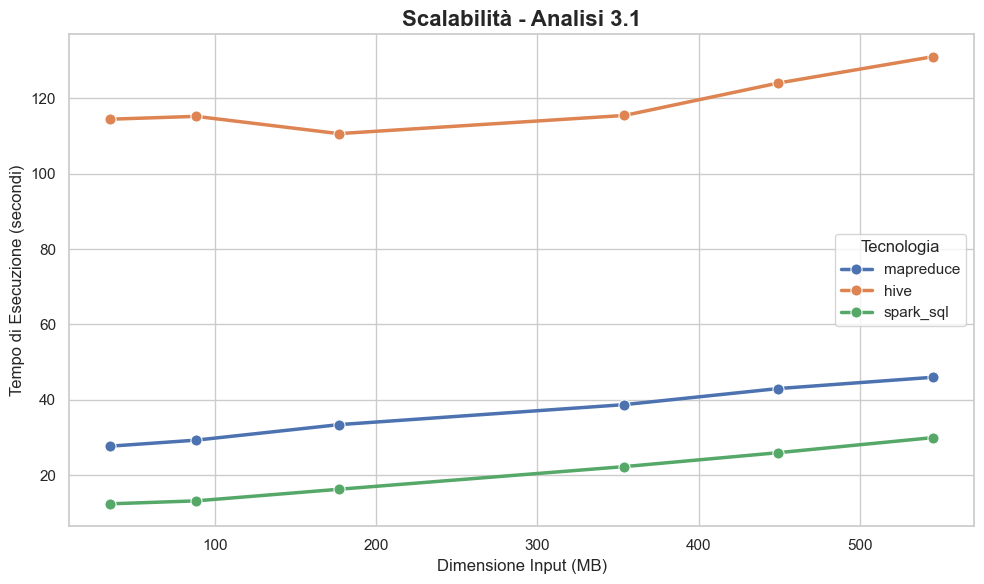

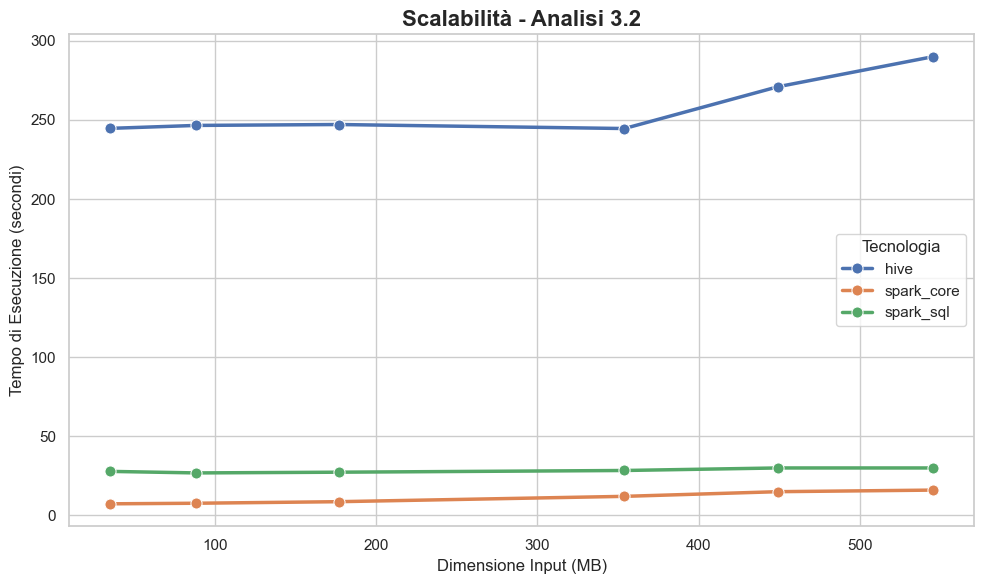

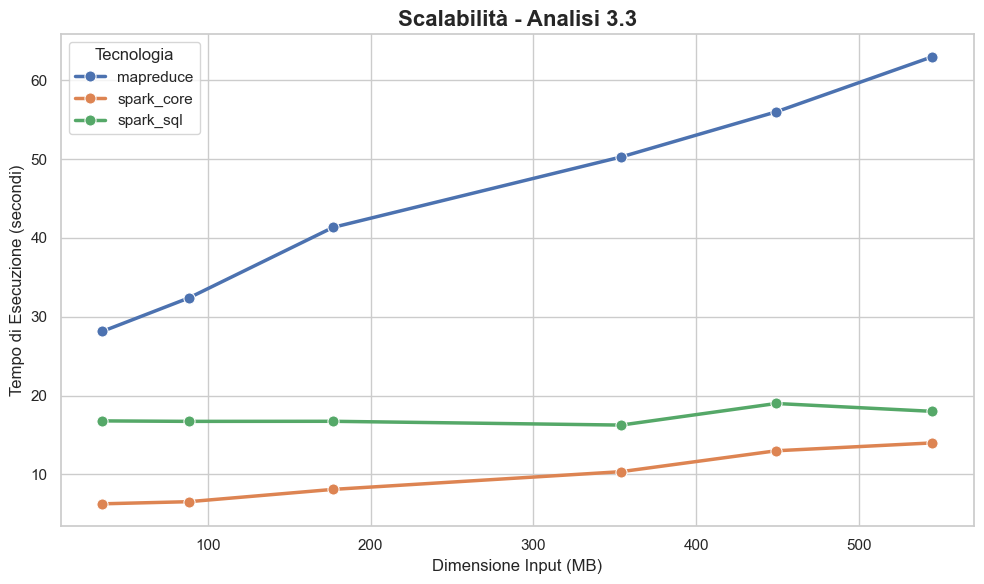

In [2]:
analyses = df['analysis'].unique()

for analisi in sorted(analyses):
    plt.figure(figsize=(10, 6))
    df_subset = df[df['analysis'] == analisi]
    
    sns.lineplot(data=df_subset, x='input_size_mb', y='elapsed_sec', hue='technology', marker='o', linewidth=2.5, markersize=8)
    
    plt.title(f'Scalabilità - Analisi {analisi}', fontsize=16, fontweight='bold')
    plt.xlabel('Dimensione Input (MB)', fontsize=12)
    plt.ylabel('Tempo di Esecuzione (secondi)', fontsize=12)
    plt.legend(title='Tecnologia', title_fontsize=12)
    plt.tight_layout()
    
    # Salvataggio del grafico
    plt.savefig(f'plots/scalabilita_analisi_{analisi}.png', dpi=300)
    plt.show()

## 2. Confronto Globale sul Dataset Completo
Vediamo un confronto a barre diretto per ciascuna analisi eseguita sul dataset da 100% (~354 MB).

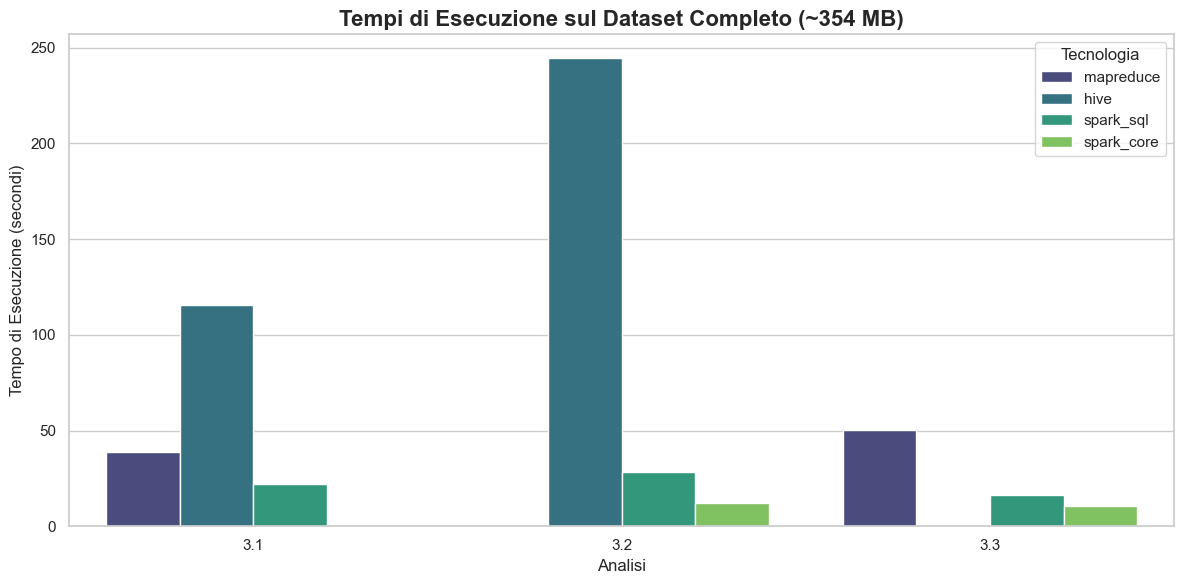

In [3]:
df_full = df[df['notes'] == 'full_dataset']

plt.figure(figsize=(12, 6))
sns.barplot(data=df_full, x='analysis', y='elapsed_sec', hue='technology', palette='viridis')

plt.title('Tempi di Esecuzione sul Dataset Completo (~354 MB)', fontsize=16, fontweight='bold')
plt.xlabel('Analisi', fontsize=12)
plt.ylabel('Tempo di Esecuzione (secondi)', fontsize=12)
plt.legend(title='Tecnologia', title_fontsize=12)
plt.tight_layout()

plt.savefig('plots/confronto_full_dataset.png', dpi=300)
plt.show()

## 3. Matrice di Rapporto (Moltiplicatore di tempo)
Quante volte è più lenta una tecnologia rispetto al benchmark di riferimento (Spark SQL)?

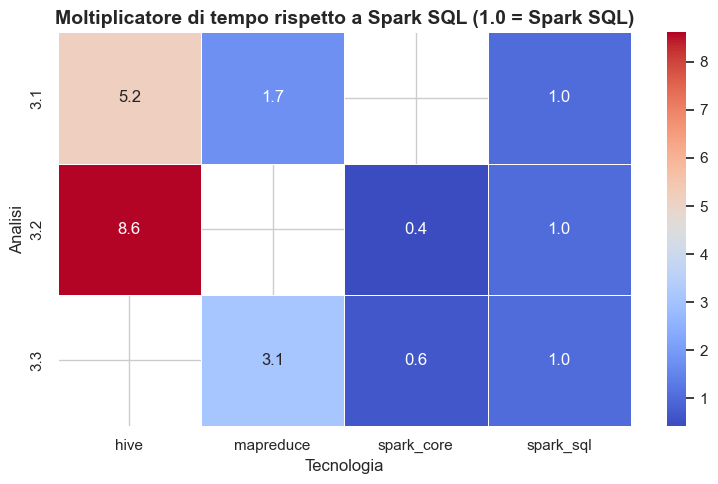

In [4]:
pivot_df = df_full.pivot(index='analysis', columns='technology', values='elapsed_sec')

if 'spark_sql' in pivot_df.columns:
    ratio_df = pivot_df.div(pivot_df['spark_sql'], axis=0)
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(ratio_df, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
    plt.title('Moltiplicatore di tempo rispetto a Spark SQL (1.0 = Spark SQL)', fontsize=14, fontweight='bold')
    plt.ylabel('Analisi', fontsize=12)
    plt.xlabel('Tecnologia', fontsize=12)
    plt.tight_layout()
    plt.savefig('plots/rapporto_spark_sql.png', dpi=300)
    plt.show()